Unsupervised Machine Learning | Dimensionality Reduction

In this project, we analyse the behavioural patterns of 8,950 credit card 
customers using Principal Component Analysis (PCA) for dimensionality 
reduction and K-Means for clustering. The goal is to identify distinct 
customer segments that can inform targeted business strategies.

*Dataset*: CC General — Kaggle  
*Techniques:* PCA, K-Means Clustering, StandardScaler  
*Libraries:* pandas, numpy, scikit-learn, matplotlib, seaborn

Step 1 : Loading and Exploring the Data
Explore :
        Shape of the data, missing values and data types. 

In [2]:
import pandas as pd


df = pd.read_csv("CC General.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [4]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Step 2 : Data Cleaning

After inspecting pour data set we see that two columns(MINIMUM PAYMENTS and CREDIT_LIMIT) have missing values

We impute the median rather the mean -why-financial data tends to be biased towards the highest spenders and n=thus not representing the average customers;median is more robust to these outliers

In [5]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

Part of cleaning data also involves removing duplicates values to ensure data integrity.

In [6]:
print(df.duplicated().sum())
df = df.drop_duplicates()

0


During exploration of data and cleaning, we check to see if any columns are identifiers rather than features, in our case, CUST_ID is an identifier, with no predictive value thus useless in our dataset-its dropped.

In [7]:
df = df.drop('CUST_ID', axis=1)

In [8]:
print (df.isnull().sum())
print(df.shape)

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64
(8950, 17)


Step 3 : Feature Scaling

PCA is higly sensitive to the scale of features. 
To solve that, I used StandardScaler to transform each feature to a common scale.
standarsScaler achieves this by transforming all th =e features to have a mean of 0 and a Standard Deviation of 1.

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']].agg(['mean', 'std']).round(2)


,BALANCE,PURCHASES,CREDIT_LIMIT
mean,0.0,0.0,0.0
std,1.0,1.0,1.0


Step 4 : Principal Component Analysis

Having perfomed the necessary data preprocessing, we move on to one of the main purposes of the project; PCA.
We use PCA for all the 17 components available to understand how variance is didtributed across them.
The scree plot(Cumulative Explanied Variance plot) helsp us identify the optimal value odf components needed for our dataset.

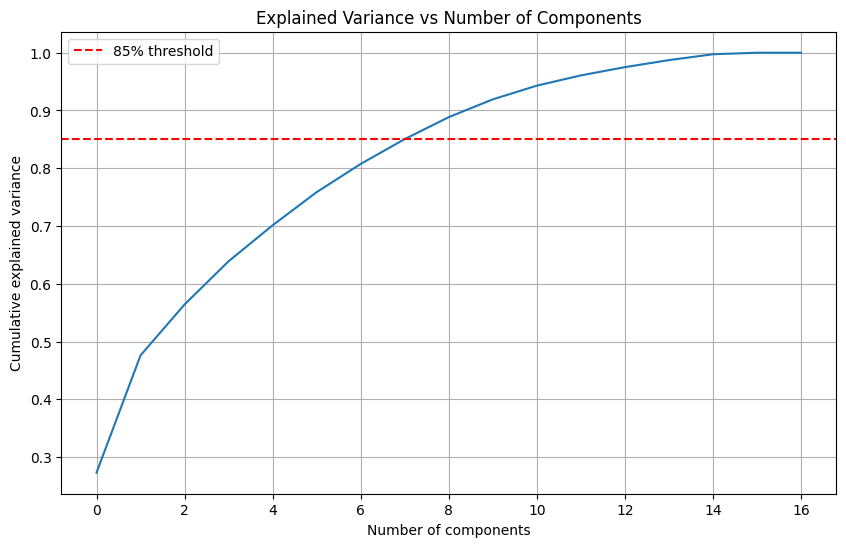

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(scaled_df)

# plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('Explained Variance vs Number of Components')
plt.axhline(y=0.85, color='r', linestyle='--', label='85% threshold')
plt.legend()
plt.grid(True)
plt.show()

After identifying our "elbow" - the sweetspot beyond which any relevant changes ae very negligible thus any more components will be unnecessary.
From 17 components, our scree plot shows 6 components are good enough.

In [12]:
pca = PCA(n_components=6)
pca.fit(scaled_df)
pca_data = pca.transform(scaled_df)

In [13]:
pca_df = pd.DataFrame(data=pca_data, columns=[f'PC{i+1}' for i in range(6)])
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6
0,-1.683649,-1.072241,-0.475660,0.679928,-0.043195,-0.068069
1,-1.134085,2.509150,-0.602216,-0.109542,-0.662638,1.102255
2,0.969395,-0.383577,-0.090970,1.238359,2.166584,0.320185
3,-0.888220,0.004648,-1.499800,1.075271,-0.225828,0.171540
4,-1.600021,-0.683795,-0.347927,1.013642,0.453816,-0.077004


Step 5 : K-MEANS 
Finding Optimal Number of Clusters

Before running K-means we decide how many clusters(k) to use, by applying the "elbow" method.

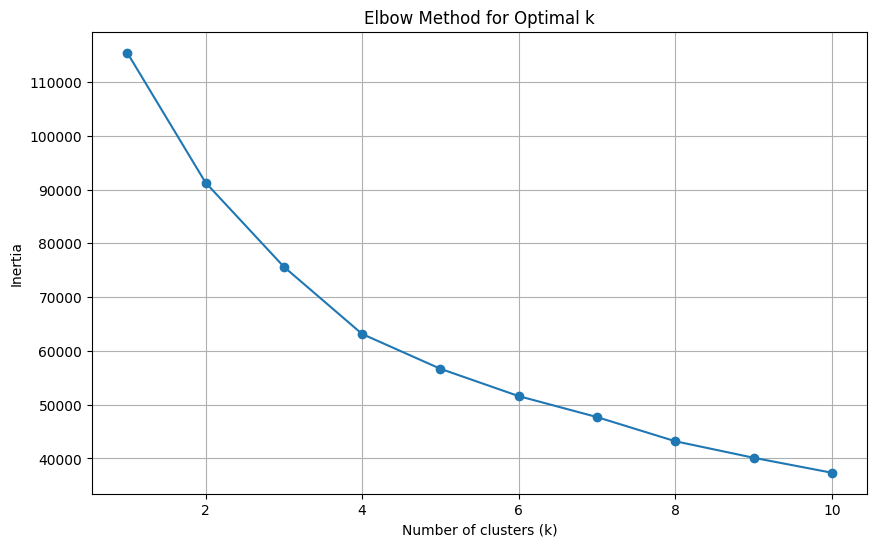

In [14]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_df)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

The graph above shows our elbow appears around 4 to 5, we'll go with 5

In [15]:
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
pca_df['Cluster'] = km_final.fit_predict(pca_df)

# confirm cluster sizes
print(pca_df['Cluster'].value_counts())

Cluster
1    3905
3    3010
2    1198
0     807
4      30
Name: count, dtype: int64


Step 6 : Visualizing Customer Segments

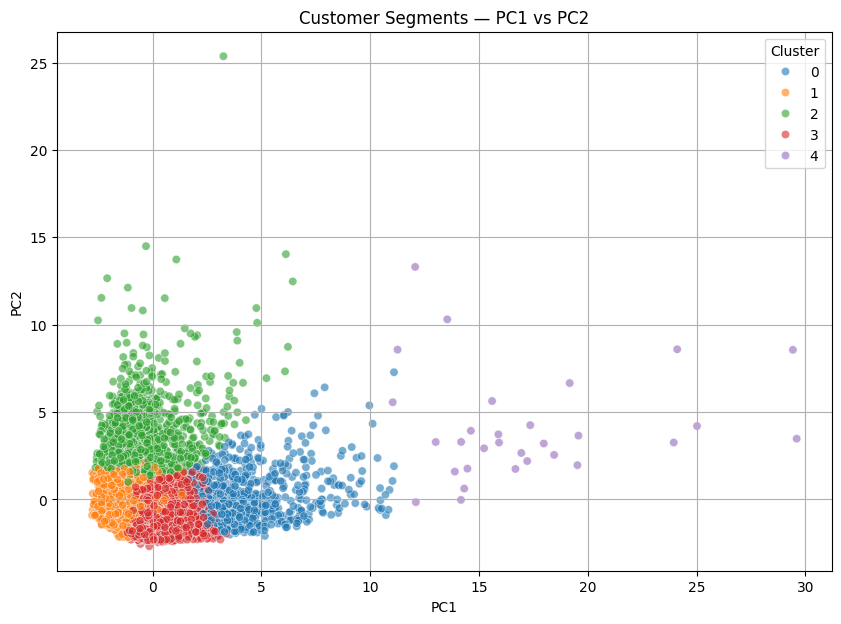

In [16]:
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster',
                palette='tab10', data=pca_df,
                alpha=0.6, legend='full')
plt.title('Customer Segments — PC1 vs PC2')
plt.grid(True)
plt.show()

In [17]:
# add cluster labels back to original dataframe
df['Cluster'] = pca_df['Cluster'].values

# compare clusters on original feature means
cluster_profile = df.groupby('Cluster').mean().round(2)
print(cluster_profile.T)  # .T transposes so clusters are columns

Cluster                                 0        1        2        3         4
BALANCE                           2601.05  1047.96  4490.25   752.29   5567.14
BALANCE_FREQUENCY                    0.98     0.79     0.97     0.92      0.96
PURCHASES                         4599.77   281.46   459.66   952.87  24957.91
ONEOFF_PURCHASES                  3016.80   228.22   289.48   360.18  18186.88
INSTALLMENTS_PURCHASES            1583.72    53.44   170.27   593.09   6771.03
CASH_ADVANCE                       503.14   593.03  4529.77   184.93   1858.84
PURCHASES_FREQUENCY                  0.95     0.17     0.27     0.87      0.91
ONEOFF_PURCHASES_FREQUENCY           0.73     0.09     0.13     0.22      0.77
PURCHASES_INSTALLMENTS_FREQUENCY     0.73     0.07     0.17     0.72      0.75
CASH_ADVANCE_FREQUENCY               0.07     0.11     0.49     0.04      0.08
CASH_ADVANCE_TRX                     1.52     2.09    14.45     0.75      3.67
PURCHASES_TRX                       62.82     2.95  

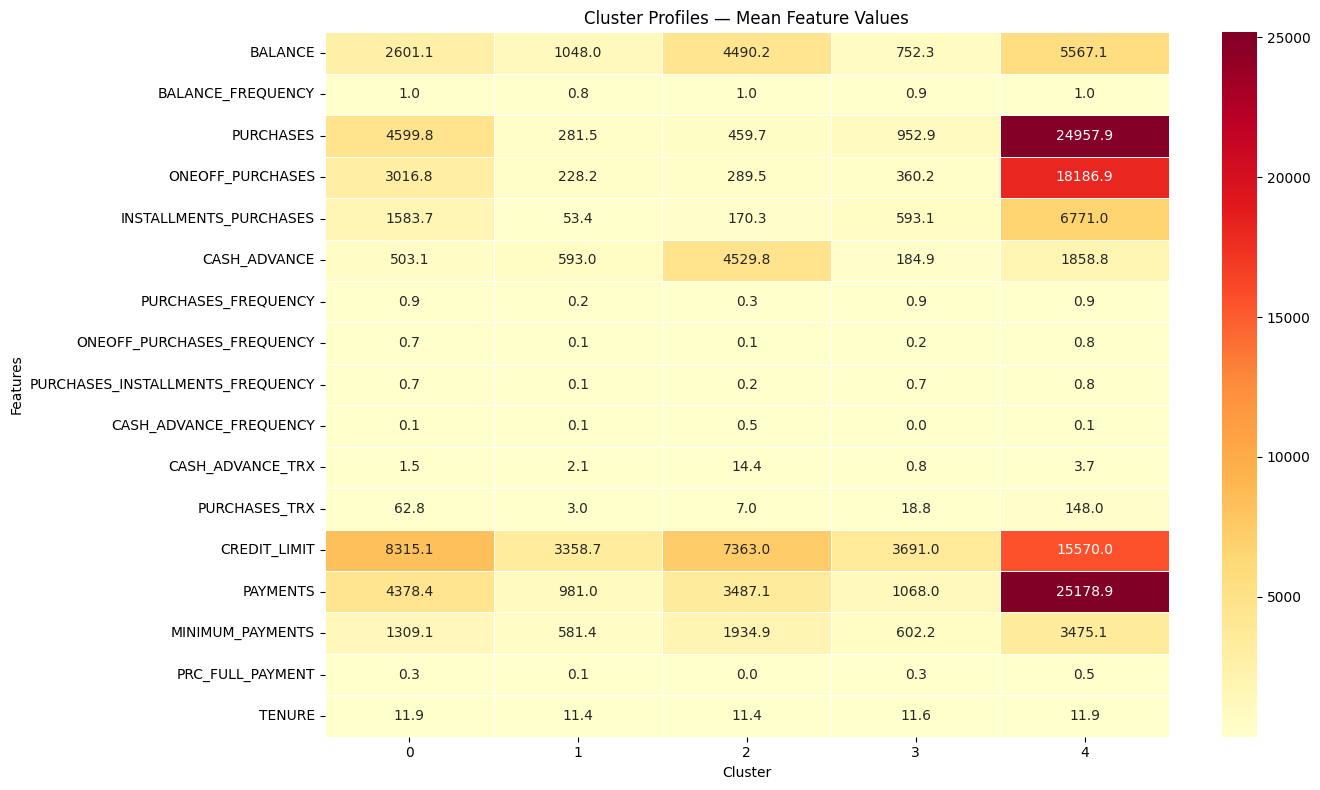

In [18]:
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profile.T, annot=True, fmt='.1f', 
            cmap='YlOrRd', linewidths=0.5)
plt.title('Cluster Profiles — Mean Feature Values')
plt.ylabel('Features')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

Interpreting the Customer Segments

We map cluster labels back to the original unscaled data and compute 
mean feature values per cluster. This is the most important step — 
it transforms mathematical output into actionable business insight.

| Cluster | Label | Size | Defining Behaviour |

| 0 | Active High-Value Shoppers | 807 | High purchases, high frequency, low cash advance |
| 1 | Inactive Low Engagers | 3,905 | Minimal card usage — highest churn risk |
| 2 | Cash Advance Dependent | 1,198 | Borrowers not spenders — credit risk flag |
| 3 | Installment Shoppers | 3,010 | Steady, prefer paying in installments |
| 4 | VIP Whales | 30 | 25x average purchases — premium customers |

# Business Recommendations
- *Cluster 1:* Launch a re-engagement campaign with cashback incentives
- *Cluster 2:* Flag for credit risk review — near-zero full payment rate
- *Cluster 3:* Target with installment plan promotions and partnerships
- *Cluster 4:* Assign dedicated relationship managers + exclusive rewards